# Sequential bagel analysis

## Install the package

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Using GitHub PAT from the git credential store.




Running `R CMD build`...



* checking for file ‘/tmp/RtmpDiBsQj/remotes3fc8c7d05fb9/grosed-bagel-3006020/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.6.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check version

In [2]:
packageVersion("bagelR")

[1] ‘1.6.0’

## Load library

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




### Example - single change in mean

#### Define the feature vector function 

In [4]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

#### Define the prior function

In [5]:
prior <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Define the transform function

In [6]:
transform <- function(tau)
{
	return(matrix(c(1,1),1,2,byrow=TRUE))
}

#### Generate some data - change at t = 501 

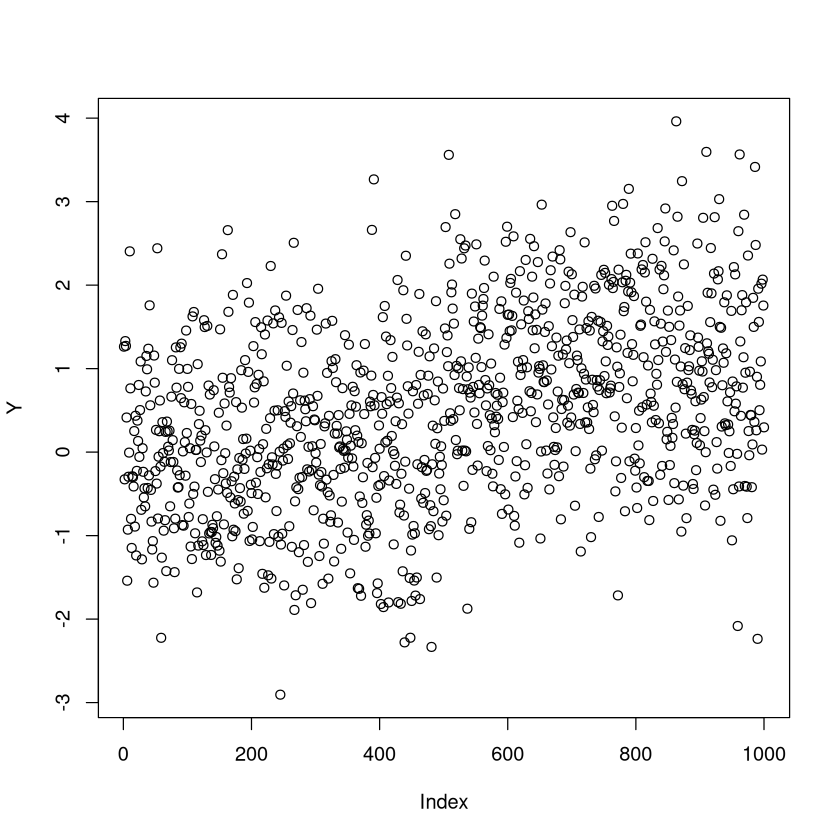

In [7]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

#### Set model parameters 

In [8]:
p <- 1.0;
p0 <- 0.9;
# noise_sd <- 1.0;
noise_nu <- 1.0
noise_iota <- 1.0 
max_particles <- 200
threshold <- 0.8

#### Create bagel object - unknown variance

In [9]:
bagel_object <- sequential_bagel_uv_approximate(feature_vector,prior,transform,p0,p,noise_nu,noise_iota,max_particles)

#### Analyse the first 300 data points

In [10]:
w0ts <- list()
for(y in Y[1:300])
{
   w0t <- update(bagel_object,y)
   w0ts <- append(w0ts,w0t)
   if(1.0 - w0t > threshold)
    {
	   break
    }
}

#### Examine progress

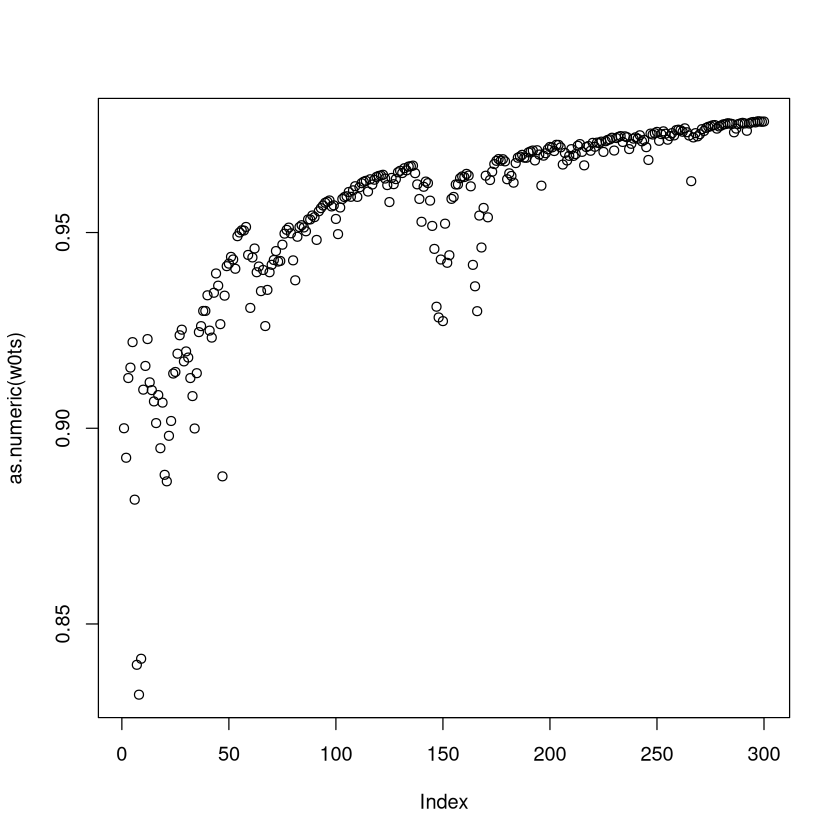

In [11]:
plot(as.numeric(w0ts))

#### Restart the analysis

In [12]:
for(y in Y[301:800])
{
   w0t <- update(bagel_object,y)
   w0ts <- append(w0ts,w0t)
   if(1.0 - w0t > threshold)
    {
	   break
    }
}

#### Examine progress

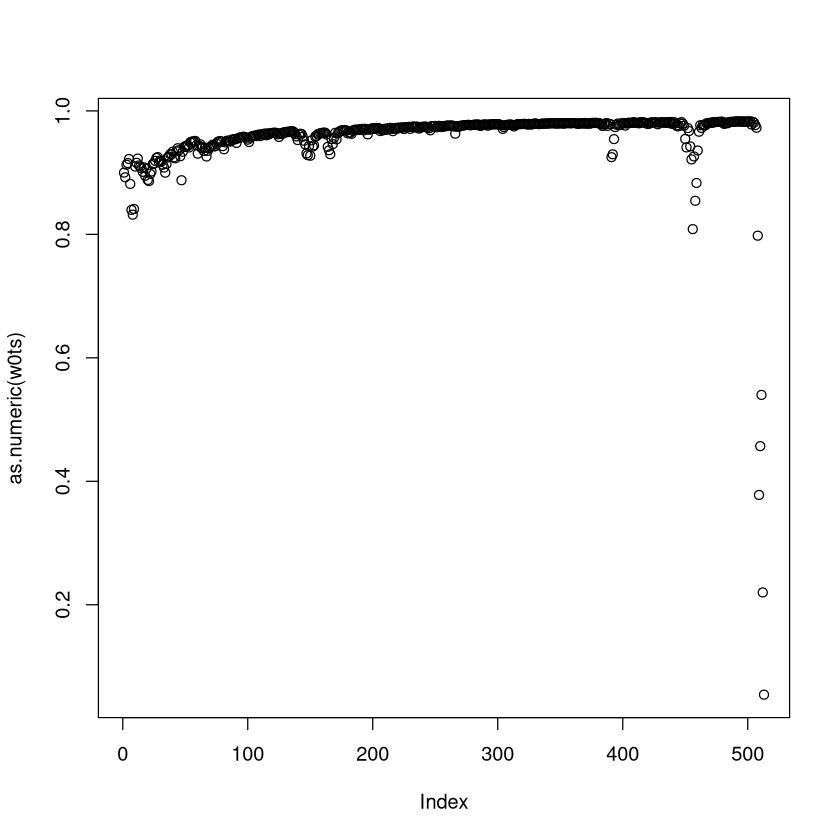

In [13]:
plot(as.numeric(w0ts))

#### Detection time

In [14]:
time(bagel_object)

[1] 513

#### Predicted changepoint location

In [15]:
which.max(weights(bagel_object))

[1] 502

#### Weight distribution around predicted changepoint

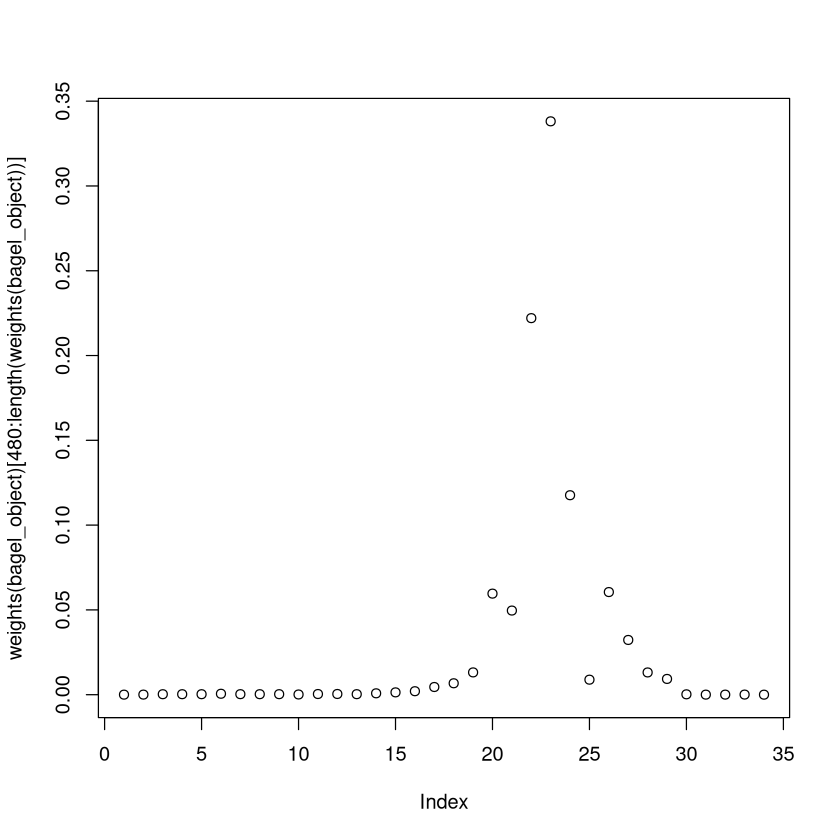

In [16]:
plot(weights(bagel_object)[480:length(weights(bagel_object))])

## Other methods available for sequential analyses

### Get the weights (reconstructed from the ratios)

In [17]:
weights(bagel_object)

[1] 5.439043e-02 1.279345e-05 7.837776e-06 1.099130e-05 1.718112e-05
  [6] 1.656998e-05 6.537265e-06 4.774427e-06 4.185573e-06 3.934212e-06
 [11] 5.800600e-06 6.892375e-06 4.977506e-06 3.937009e-06 3.558288e-06
 [16] 3.261772e-06 2.998823e-06 2.984735e-06 2.710400e-06 2.709467e-06
 [21] 2.621452e-06 2.570145e-06 2.503885e-06 2.460080e-06 2.365036e-06
 [26] 2.312361e-06 2.326370e-06 2.474419e-06 2.293076e-06 2.215577e-06
 [31] 2.188899e-06 2.152032e-06 2.169237e-06 2.156104e-06 2.189994e-06
 [36] 2.098934e-06 1.975432e-06 2.014807e-06 1.957795e-06 2.003577e-06
 [41] 1.937081e-06 2.066032e-06 2.166876e-06 2.027494e-06 1.911641e-06
 [46] 1.860967e-06 1.804452e-06 1.839441e-06 1.766370e-06 1.757798e-06
 [51] 1.730695e-06 1.731465e-06 1.710949e-06 1.762264e-06 1.664412e-06
 [56] 1.644424e-06 1.654471e-06 1.701382e-06 1.662601e-06 1.680653e-06
 [61] 1.651530e-06 1.632684e-06 1.625389e-06 1.733491e-06 1.728251e-06
 [66] 1.772638e-06 1.747304e-06 1.859173e-06 1.787016e-06 1.749674e-06
 [71] 1.736437e-06 1.729085e-06 1.697007e-06 1.757850e-06 1.766733e-06
 [76] 1.684127e-06 1.630692e-06 1.620967e-06 1.620493e-06 1.638332e-06
 [81] 1.815484e-06 1.931922e-06 1.714408e-06 1.637060e-06 1.647363e-06
 [86] 1.702096e-06 1.744109e-06 1.613320e-06 1.639360e-06 1.506895e-06
 [91] 1.472456e-06 1.477886e-06 1.442684e-06 1.441743e-06 1.455953e-06
 [96] 1.439290e-06 1.435920e-06 1.432382e-06 1.344578e-06 1.343958e-06
[101] 1.288358e-06 1.302323e-06 1.361195e-06 1.342899e-06 1.345259e-06
[106] 1.334026e-06 1.327930e-06 1.338331e-06 1.317609e-06 1.316576e-06
[111] 1.288643e-06 1.272386e-06 1.337359e-06 1.339216e-06 1.340783e-06
[116] 1.353436e-06 1.316058e-06 1.347457e-06 1.335951e-06 1.297423e-06
[121] 1.300136e-06 1.299412e-06 1.294604e-06 1.427223e-06 1.465019e-06
[126] 1.501284e-06 1.340514e-06 1.339247e-06 1.338250e-06 1.321329e-06
[131] 1.324572e-06 1.253112e-06 1.255323e-06 1.233662e-06 1.262484e-06
[136] 1.238778e-06 1.280546e-06 1.395140e-06 1.429898e-06 1.520624e-06
[141] 1.607318e-06 1.519934e-06 1.518923e-06 1.555121e-06 1.694054e-06
[146] 1.894252e-06 1.995902e-06 2.235259e-06 2.374676e-06 2.236667e-06
[151] 2.573336e-06 2.300615e-06 2.491480e-06 2.538623e-06 2.020559e-06
[156] 1.835544e-06 1.898831e-06 2.033920e-06 1.897091e-06 1.916551e-06
[161] 2.009317e-06 1.940423e-06 1.993797e-06 1.573998e-06 1.337658e-06
[166] 1.362955e-06 1.302271e-06 1.341701e-06 1.298338e-06 1.311142e-06
[171] 1.326860e-06 1.293239e-06 1.291705e-06 1.308124e-06 1.359107e-06
[176] 1.430929e-06 1.384572e-06 1.573395e-06 1.593021e-06 1.638505e-06
[181] 1.938519e-06 1.967316e-06 1.951562e-06 2.068514e-06 1.890578e-06
[186] 1.767391e-06 1.798505e-06 1.782059e-06 1.893648e-06 1.950751e-06
[191] 1.738780e-06 1.758469e-06 1.742287e-06 1.505475e-06 1.564368e-06
[196] 1.439489e-06 1.336372e-06 1.373967e-06 1.390288e-06 1.436457e-06
[201] 1.479668e-06 1.613128e-06 1.732671e-06 1.538087e-06 1.482656e-06
[206] 1.417041e-06 1.280666e-06 1.309293e-06 1.260529e-06 1.274712e-06
[211] 1.301770e-06 1.221141e-06 1.238610e-06 1.315259e-06 1.333918e-06
[216] 1.194910e-06 1.168215e-06 1.227741e-06 1.240529e-06 1.225200e-06
[221] 1.257164e-06 1.222748e-06 1.225748e-06 1.228559e-06 1.242440e-06
[226] 1.157946e-06 1.256092e-06 1.273125e-06 1.324749e-06 1.299941e-06
[231] 1.165847e-06 1.234481e-06 1.253275e-06 1.270746e-06 1.191266e-06
[236] 1.218242e-06 1.208828e-06 1.137934e-06 1.143572e-06 1.160698e-06
[241] 1.172584e-06 1.160161e-06 1.215323e-06 1.115433e-06 1.137018e-06
[246] 1.380655e-06 1.361870e-06 1.382980e-06 1.333405e-06 1.348349e-06
[251] 1.371012e-06 1.527179e-06 1.480061e-06 1.445719e-06 1.268373e-06
[256] 1.173165e-06 1.192815e-06 1.209685e-06 1.194279e-06 1.215311e-06
[261] 1.233436e-06 1.221967e-06 1.291841e-06 1.264527e-06 1.139939e-06
[266] 1.147386e-06 1.067102e-06 1.166967e-06 1.151538e-06 1.205190e-06
[271] 1.260052e-06 1.227713e-06 1.246465e-06 1.259381e-06 1.212363e-06
[276] 1.223356e-06 1.229393e-06 1.241010e-06 1.199304e-06 1.186830e-06
[281] 1.265639e-06 1.25943

#### Get the active weights

In [18]:
active_weights(bagel_object)

[1] 5.439043e-02 2.063122e-05 1.099130e-05 3.375110e-05 6.537265e-06
  [6] 1.289421e-05 1.269297e-05 4.977506e-06 2.216049e-05 1.015556e-05
 [11] 1.177126e-05 6.556508e-06 8.614269e-06 5.948035e-06 3.940658e-06
 [16] 6.260401e-06 1.911641e-06 1.420214e-05 1.008956e-05 6.590255e-06
 [21] 2.925927e-05 3.747406e-06 1.169772e-05 1.310521e-05 2.688536e-06
 [26] 2.590681e-06 1.068382e-05 2.561029e-06 1.456184e-05 4.393525e-06
 [31] 6.663912e-06 6.243359e-06 1.280546e-06 2.825038e-06 7.721920e-06
 [36] 1.694054e-06 3.890154e-06 6.846603e-06 9.904054e-06 1.754603e-05
 [41] 1.573998e-06 1.317399e-05 4.174608e-06 4.804920e-06 7.925912e-06
 [46] 7.238532e-06 3.844399e-06 5.239537e-06 3.069843e-06 5.540116e-06
 [51] 2.916124e-06 3.345799e-06 4.437784e-06 6.426970e-06 2.459752e-06
 [56] 2.649177e-06 2.363126e-06 9.870128e-06 1.157946e-06 5.153908e-06
 [61] 1.165847e-06 3.758502e-06 3.618336e-06 5.774949e-06 1.215323e-06
 [66] 2.252451e-06 8.178272e-06 4.452959e-06 9.709031e-06 2.556367e-06
 [71] 2.287325e-06 1.067102e-06 2.318505e-06 1.110492e-05 2.386134e-06
 [76] 5.084722e-06 9.501119e-06 1.125964e-06 1.079586e-05 2.242797e-06
 [81] 2.179168e-06 5.777416e-06 6.834537e-06 4.995655e-06 4.118542e-06
 [86] 3.120746e-06 1.448084e-06 3.825167e-06 2.726086e-06 1.128266e-05
 [91] 8.147460e-06 4.998908e-06 2.664548e-06 1.022915e-05 1.368370e-06
 [96] 3.757845e-06 2.435020e-06 2.618656e-06 3.055363e-06 1.433079e-06
[101] 3.217005e-06 3.492999e-06 3.238006e-06 1.469746e-06 3.513061e-06
[106] 3.790595e-06 4.781761e-06 2.687443e-06 4.733009e-06 2.170410e-06
[111] 3.454974e-06 1.650521e-06 3.894494e-06 3.002662e-06 1.651644e-06
[116] 1.038021e-05 2.589447e-06 4.716430e-06 1.965561e-06 5.054465e-06
[121] 4.169507e-06 5.244383e-06 1.662368e-06 4.130918e-06 1.951794e-06
[126] 1.747077e-06 3.275233e-06 3.069286e-06 8.832563e-06 1.705429e-06
[131] 1.515249e-06 3.281788e-06 3.776220e-06 6.871335e-06 2.826088e-06
[136] 2.245416e-06 2.496084e-06 7.312656e-06 2.635289e-06 2.204476e-06
[141] 7.742185e-06 2.223441e-06 3.020078e-06 3.733725e-06 5.379178e-06
[146] 6.887584e-06 6.058092e-06 7.681497e-06 1.184701e-05 1.637136e-05
[151] 2.969908e-05 2.427918e-05 9.640839e-05 4.279243e-05 3.005091e-05
[156] 1.722414e-05 3.303868e-05 2.570247e-05 7.673376e-05 2.487841e-05
[161] 3.337317e-05 6.228552e-05 4.153441e-05 1.107740e-04 3.107217e-05
[166] 2.396460e-05 3.773610e-05 2.631067e-05 3.751485e-05 6.200503e-05
[171] 5.899411e-04 2.995336e-04 5.594935e-04 3.211063e-04 6.175066e-04
[176] 1.307513e-04 4.038473e-04 4.265982e-04 3.113746e-04 8.203636e-04
[181] 1.374611e-03 2.056279e-03 4.540780e-03 6.741198e-03 1.315005e-02
[186] 5.960835e-02 4.962360e-02 2.220521e-01 3.381014e-01 1.176297e-01
[191] 8.862552e-03 6.052949e-02 3.228718e-02 1.312548e-02 9.302058e-03
[196] 2.263336e-04 4.294141e-05 5.067460e-05 7.639793e-05 2.150649e-05

#### Get the ratios

In [19]:
ratios(bagel_object)

[[1]]
[1] 1

[[2]]
[1] 0.6201012 0.3798988

[[3]]
[1] 1

[[4]]
[1] 0.5090535 0.4909465

[[5]]
[1] 1

[[6]]
[1] 0.3702767 0.3246087 0.3051145

[[7]]
[1] 0.4569929 0.5430071

[[8]]
[1] 1

[[9]]
[1] 0.1776589 0.1605690 0.1471886 0.1353229 0.1346872 0.1223077 0.1222656

[[10]]
[1] 0.2581297 0.2530776 0.2465531 0.2422396

[[11]]
[1] 0.2009161 0.1964412 0.1976313 0.2102085 0.1948029

[[12]]
[1] 0.3379202 0.3338514 0.3282284

[[13]]
[1] 0.2518190 0.2502945 0.2542286 0.2436579

[[14]]
[1] 0.332115 0.338735 0.329150

[[15]]
[1] 0.5084372 0.4915628

[[16]]
[1] 0.3300159 0.3461241 0.3238600

[[17]]
[1] 1

[[18]]
[1] 0.1310343 0.1270549 0.1295186 0.1243735 0.1237700 0.1218616 0.1219158
[8] 0.1204713

[[19]]
[1] 0.1746622 0.1649639 0.1629828 0.1639786 0.1686281 0.1647844

[[20]]
[1] 0.2550209 0.2506018 0.2477422 0.2466351

[[21]]
 [1] 0.05924589 0.05906678 0.06058382 0.05971797 0.06354135 0.06107522
 [7] 0.05979896 0.05934655 0.05909528 0.05799893 0.06007841 0.06038199
[13] 0.05755874 0.05573248 0.05540012 0.05538392 0.05599360

[[22]]
[1] 0.4844643 0.5155357

[[23]]
[1] 0.1465592 0.1399470 0.1408278 0.1455067 0.1490982 0.1379175 0.1401436

[[24]]
[1] 0.1149844 0.1123566 0.1127709 0.1100848 0.1100130 0.1110973 0.1098258
[8] 0.1095686 0.1092987

[[25]]
[1] 0.5001154 0.4998846

[[26]]
[1] 0.4973048 0.5026952

[[27]]
[1] 0.1274071 0.1256946 0.1259155 0.1248641 0.1242935 0.1252671 0.1233275
[8] 0.1232308

[[28]]
[1] 0.5031741 0.4968259

[[29]]
 [1] 0.09184003 0.09196753 0.09207515 0.09294403 0.09037724 0.09253345
 [7] 0.09174328 0.08909748 0.08928382 0.08923407 0.08890392

[[30]]
[1] 0.3248469 0.3334495 0.3417036

[[31]]
[1] 0.2011603 0.2009701 0.2008204 0.1982813 0.1987679

[[32]]
[1] 0.2007112 0.2010653 0.1975959 0.2022123 0.1984152

[[33]]
[1] 1

[[34]]
[1] 0.4938482 0.5061518

[[35]]
[1] 0.1969230 0.2081501 0.1968337 0.1967027 0.2013905

[[36]]
[1] 1

[[37]]
[1] 0.486935 0.513065

[[38]]
[1] 0.3264772 0.3468400 0.3266828

[[39]]
[1] 0.2598265 0.2322902 0.2515617 0.2563216

[[40]]
[1] 0.1151576 0.1046130 0.1082199 0.1159191 0.1081208 0.1092299 0.1145169
[8] 0.1105904 0.1136324

[[41]]
[1] 1

[[42]]
 [1] 0.10153781 0.10345799 0.09885168 0.10184465 0.09855309 0.09952499
 [7] 0.10071815 0.09816605 0.09804966 0.09929593

[[43]]
[1] 0.3255652 0.3427697 0.3316651

[[44]]
[1] 0.3274549 0.3315395 0.3410056

[[45]]
[1] 0.2445799 0.2482132 0.2462256 0.2609812

[[46]]
[1] 0.2611825 0.2441643 0.2484627 0.2461906

[[47]]
[1] 0.4925731 0.5074269

[[48]]
[1] 0.3318576 0.3356154 0.3325270

[[49]]
[1] 0.4904078 0.5095922

[[50]]
[1] 0.2598302 0.2412173 0.2480033 0.2509493

[[51]]
[1] 0.492591 0.507409

[[52]]
[1] 0.4821353 0.5178647

[[53]]
[1] 0.3465890 0.3340983 0.3193126

[[54]]
[1] 0.1992643 0.2037186 0.1961312 0.1983380 0.2025480

[[55]]
[1] 0.496449 0.503551

[[56]]
[1] 0.4964784 0.5035216

[[57]]
[1] 0.5056482 0.4943518

[[58]]
[1] 0.1243896 0.1256852 0.1241321 0.1273705 0.1238837 0.1241876 0.1244725
[8] 0.1258788

[[59]]
[1] 1

[[60]]
[1] 0.2437164 0.2470214 0.2570379 0.2522244

[[61]]
[1] 1

[[62]]
[1] 0.3284504 0.3334506 0.3380990

[[63]]
[1] 0.3292305 0.3366857 0.3340838

[[64]]
[1] 0.1970466 0.1980229 0.2009884 0.2030467 0.2008954

[[65]]
[1] 1

[[66]]
[1] 0.4952086 0.5047914

[[67]]
[1] 0.1688199 0.1665230 0.1691042 0.1630424 0.1648697 0.1676408

[[68]]
[1] 0.3429583 0.3323769 0.3246648

[[69]]
[1] 0.1306385 0.1208324 0.1228562 0.1245938 0.1230070 0.1251733 0.1270401
[8] 0.1258588

[[70]]
[1] 0.5053423 0.4946577

[[71]]
[1] 0.4983721 0.5016279

[[72]]
[1] 1

[[73]]
[1] 0.5033275 0.4966725

[[74]]
[1] 0.1085276 0.1134679 0.1105558 0.1122444 0.1134074 0.1091734 0.1101634
[8] 0.1107070 0.1117532

[[75]]
[1] 0.5026138 0.4973862

[[76]]
[1] 0.2489101 0.2476895 0.2535601 0.2498403

[[77]]
[1] 0.1252251 0.1240150 0.1289595 0.1287965 0.1201185 0.1228133 0.1239719
[8] 0.1261001

[[78]]
[1] 1

[[79]]
[1] 0.1096156 0.1102553 0.1124059 0.1103143 0.1133302 0.1103735 0.1092375
[8] 0.1116746 0.1127932

[[80]]
[1] 0.4986577 0.5013423

[[81]]
[1] 0.503746 0.496

#### Get the weight at tau = 0

In [20]:
weights_tau_zero(bagel_object)

[1] 0.05439043

#### Get the tau values

In [21]:
taus(bagel_object)

[1]   0   2   3   5   6   9  11  12  19  23  28  31  35  38  40  43  44  52
 [19]  58  62  79  81  88  97  99 101 109 111 122 125 130 135 136 138 143 144
 [37] 146 149 153 162 163 173 176 179 183 187 189 192 194 198 200 202 205 210
 [55] 212 214 216 224 225 229 230 233 236 241 242 244 250 253 261 263 265 266
 [73] 268 277 279 283 291 292 301 303 305 310 315 319 322 324 325 328 330 339
 [91] 345 349 351 359 360 363 365 367 369 370 372 374 376 377 379 381 383 384
[109] 386 387 389 390 393 395 396 401 402 404 405 407 409 412 413 415 416 417
[127] 419 421 426 427 428 430 432 435 436 437 438 440 441 442 446 447 448 449
[145] 450 451 452 453 454 455 456 457 459 460 461 462 463 464 466 467 468 470
[163] 471 474 475 476 477 478 479 480 482 483 484 485 487 488 489 490 491 492
[181] 493 494 495 496 497 498 499 500 501 502 503 504 505 506 507 508 509 510
[199] 511 512

#### Get the time

In [22]:
time(bagel_object)

[1] 513

#### Get the maximum number of particles

In [23]:
max_particles(bagel_object)

[1] 200

#### Get the posterior means

In [24]:
mus(bagel_object)

ERROR: Error in mus(bagel_object): could not find function "mus"


#### Get the posterior sigmas

In [ ]:
sigmas(bagel_object)

#### Get the noise nus

In [ ]:
nus(bagel_object)

#### Get the noise iotas

In [ ]:
iotas(bagel_object)

#### Set the weights (used when combining analyses over multiple bagel objects)

In [ ]:
weights <- active_weights(bagel_object)
weights <- 0.5*weights
set_weights(bagel_object,weights)

In [ ]:
active_weights(bagel_object)